# Phase 2: Clustering Analysis

**Input:** Scaled feature matrix from `01_feature_engineering.ipynb` (via pickle)

**Pipeline:** Optimal k determination → K-Means (primary) → Hierarchical (validation) → DBSCAN (outlier detection) → Stability assessment → Visualizations

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Load artifacts from Phase 1
with open('feature_engineering_artifacts.pkl', 'rb') as f:
    art = pickle.load(f)

df_scaled = art['df_scaled']
df_unscaled = art['df_unscaled']
labels = art['labels']
target = art['target']
scaler = art['scaler']
pca = art['pca']
X_pca = art['X_pca']
gwu_name = art['gwu_name']
gwu_idx = art['gwu_idx']
feature_groups = art['feature_groups']

X = df_scaled.values
school_names = df_scaled.index.tolist()
ranks = labels['rank'].values

print(f"Loaded: {X.shape[0]} schools x {X.shape[1]} features")
print(f"GWU: '{gwu_name}' (rank {ranks[gwu_idx]})")

Loaded: 121 schools x 40 features
GWU: 'George Washington University' (rank 61)


## Step 2.1 — Optimal k Determination

Three methods: Elbow (WCSS), Silhouette scores, and Gap statistic.

In [2]:
K_RANGE = range(2, 16)

# ── Elbow method (WCSS / inertia) ──
inertias = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=42, max_iter=500)
    km.fit(X)
    inertias.append(km.inertia_)

# ── Silhouette scores ──
sil_scores = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=42, max_iter=500)
    km.fit(X)
    sil_scores.append(silhouette_score(X, km.labels_))

# ── Gap statistic ──
def gap_statistic(X, K_range, B=50, random_state=42):
    """Compute gap statistic: Gap(k) = E*[log(W_k)] - log(W_k)"""
    rng = np.random.RandomState(random_state)
    n, p = X.shape
    
    # Reference: uniform distribution over the range of each feature
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    
    gaps = []
    gap_stds = []
    
    for k in K_range:
        # Actual WCSS
        km = KMeans(n_clusters=k, n_init=20, random_state=42, max_iter=300)
        km.fit(X)
        log_wk = np.log(km.inertia_)
        
        # Reference WCSS (B bootstrap samples from uniform)
        ref_log_wks = []
        for _ in range(B):
            X_ref = rng.uniform(X_min, X_max, size=(n, p))
            km_ref = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
            km_ref.fit(X_ref)
            ref_log_wks.append(np.log(km_ref.inertia_))
        
        gap = np.mean(ref_log_wks) - log_wk
        sk = np.std(ref_log_wks) * np.sqrt(1 + 1/B)
        gaps.append(gap)
        gap_stds.append(sk)
    
    return gaps, gap_stds

print("Computing gap statistic (B=50 bootstrap samples)...")
gaps, gap_stds = gap_statistic(X, K_RANGE, B=50)

# Find optimal k via gap criterion: smallest k where Gap(k) >= Gap(k+1) - s(k+1)
optimal_gap_k = None
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - gap_stds[i+1]:
        optimal_gap_k = list(K_RANGE)[i]
        break

print(f"Gap statistic optimal k: {optimal_gap_k}")
print(f"Best silhouette k: {list(K_RANGE)[np.argmax(sil_scores)]} (score={max(sil_scores):.3f})")

Computing gap statistic (B=50 bootstrap samples)...


Gap statistic optimal k: 5
Best silhouette k: 2 (score=0.148)


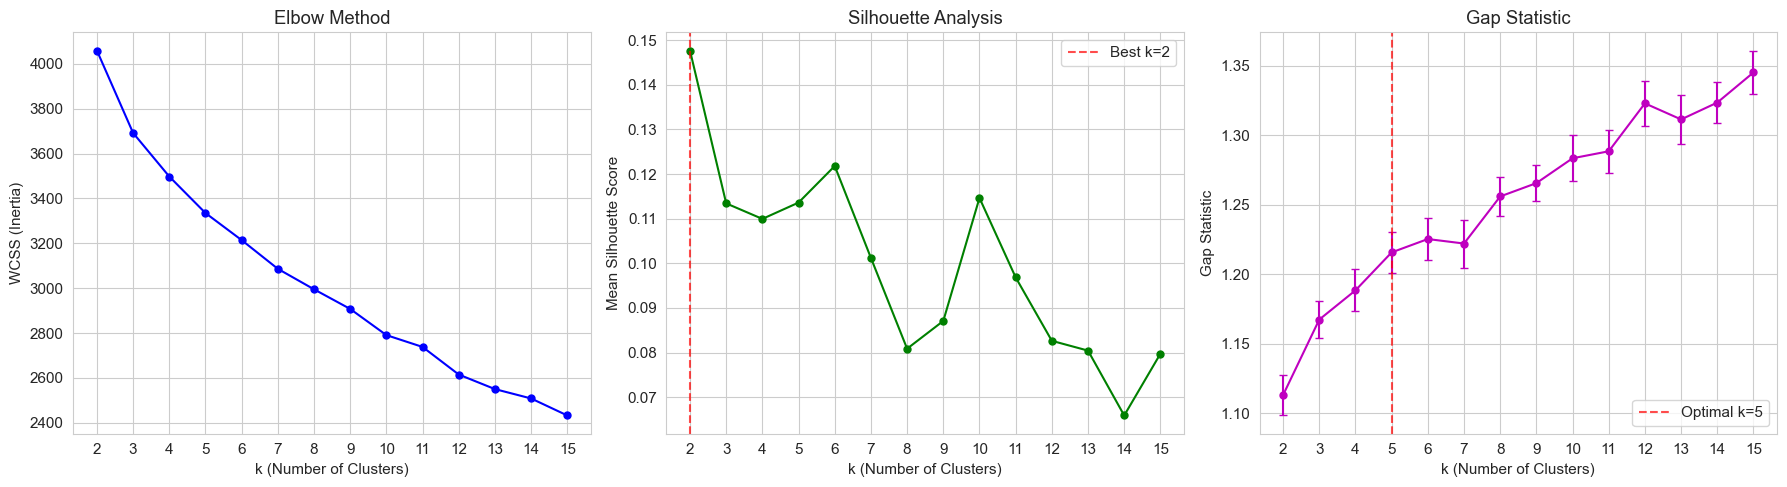


Method consensus:
  Silhouette best:    k=2 (score=0.148)
  Gap statistic:      k=5
  (Elbow is visual — check the plot for the bend)


In [3]:
# Visualization: Elbow, Silhouette, Gap Statistic
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
k_list = list(K_RANGE)

# Elbow
axes[0].plot(k_list, inertias, 'b-o', markersize=5)
axes[0].set_xlabel('k (Number of Clusters)')
axes[0].set_ylabel('WCSS (Inertia)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(k_list)

# Silhouette
axes[1].plot(k_list, sil_scores, 'g-o', markersize=5)
best_sil_k = k_list[np.argmax(sil_scores)]
axes[1].axvline(x=best_sil_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_sil_k}')
axes[1].set_xlabel('k (Number of Clusters)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(k_list)
axes[1].legend()

# Gap Statistic
axes[2].errorbar(k_list, gaps, yerr=gap_stds, fmt='m-o', markersize=5, capsize=3)
if optimal_gap_k:
    axes[2].axvline(x=optimal_gap_k, color='r', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_gap_k}')
axes[2].set_xlabel('k (Number of Clusters)')
axes[2].set_ylabel('Gap Statistic')
axes[2].set_title('Gap Statistic')
axes[2].set_xticks(k_list)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nMethod consensus:")
print(f"  Silhouette best:    k={best_sil_k} (score={max(sil_scores):.3f})")
print(f"  Gap statistic:      k={optimal_gap_k}")
print(f"  (Elbow is visual — check the plot for the bend)")

## Step 2.1b — Dendrogram (Hierarchical Clustering, Ward Linkage)

Visual confirmation of natural cluster boundaries.

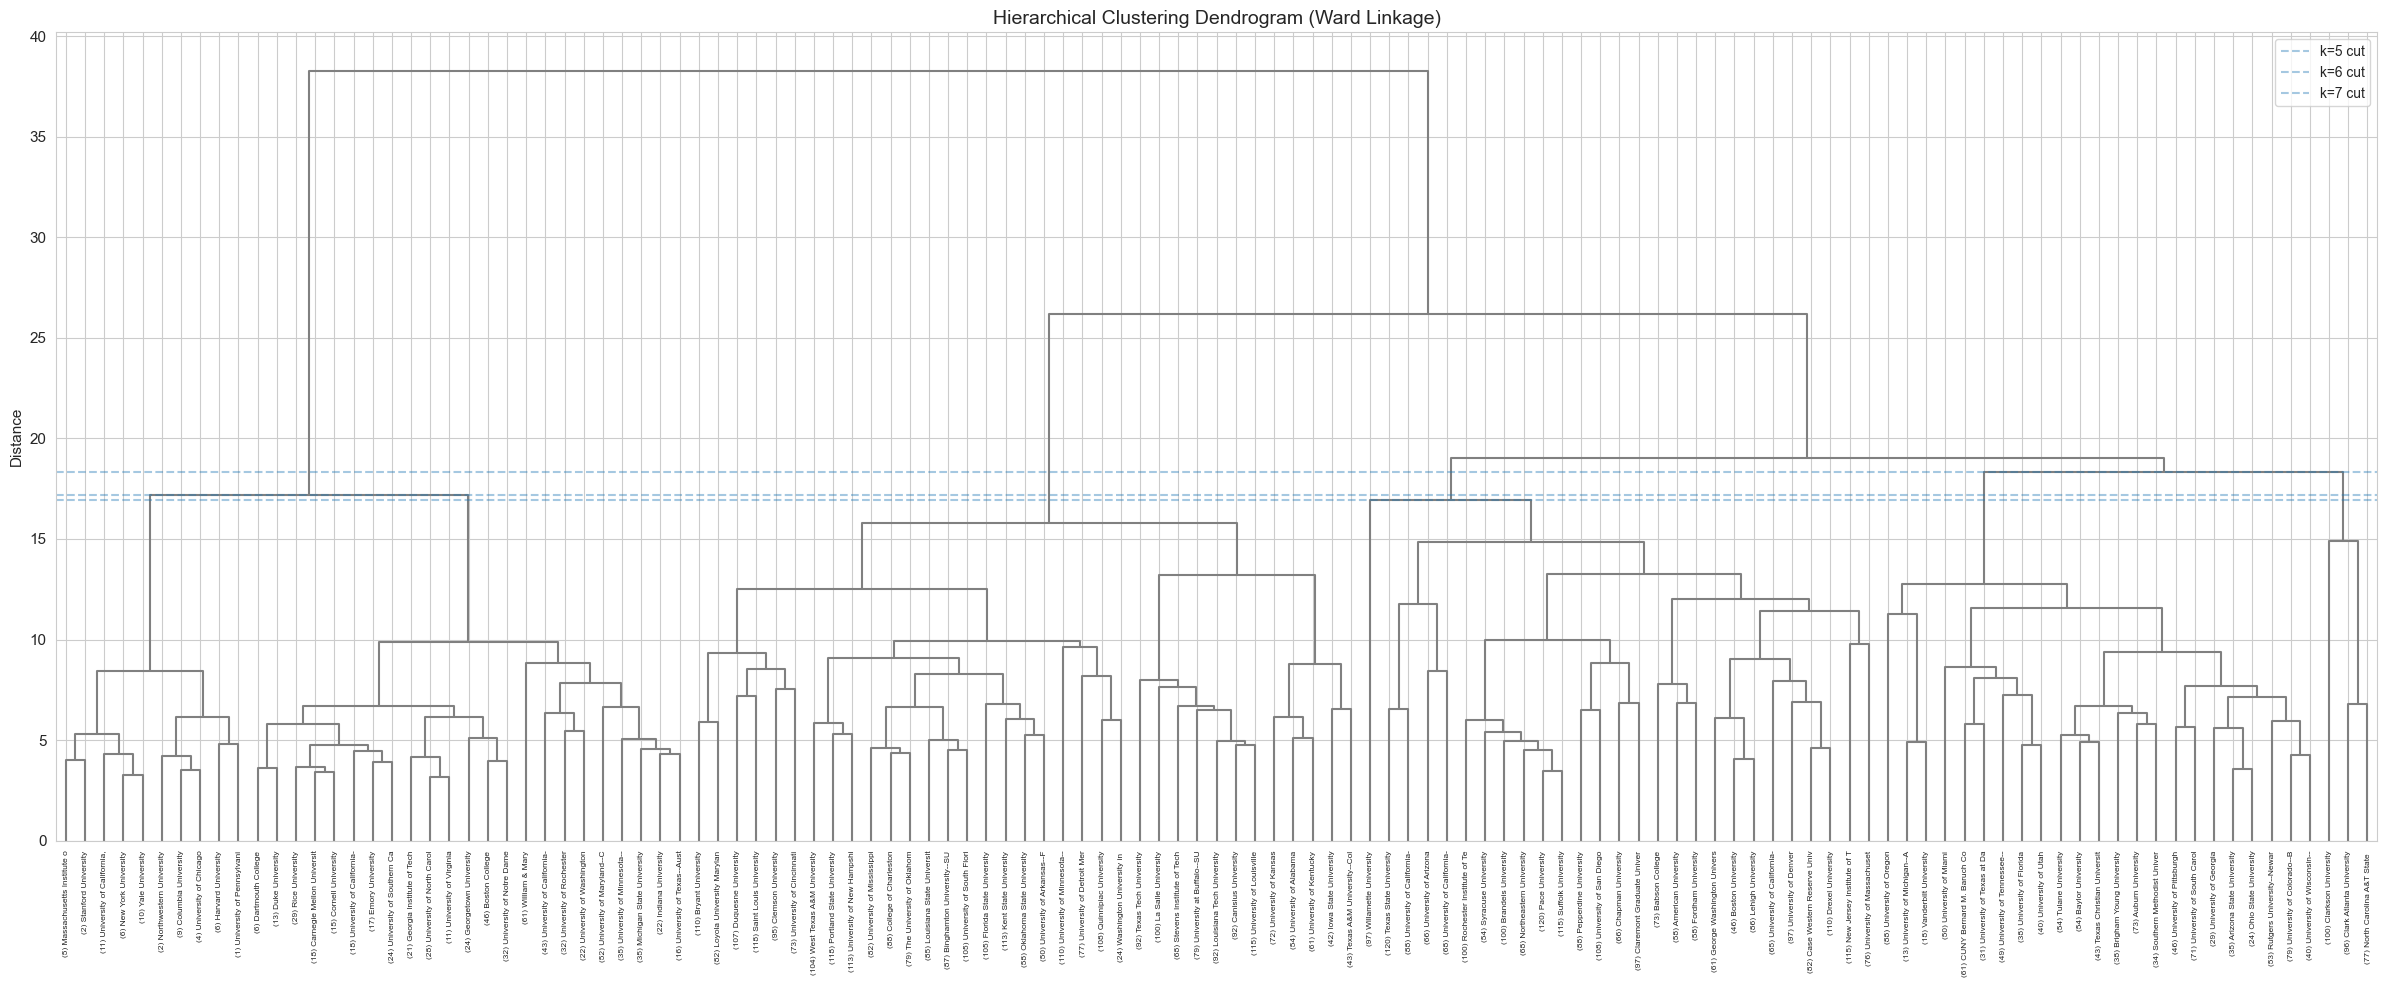

In [4]:
# Hierarchical clustering linkage matrix
Z = linkage(X, method='ward', metric='euclidean')

# Create short school labels with rank
short_labels = [f"({int(ranks[i])}) {name[:25]}" for i, name in enumerate(school_names)]

fig, ax = plt.subplots(figsize=(24, 10))
dn = dendrogram(Z, labels=short_labels, leaf_rotation=90, leaf_font_size=6,
                color_threshold=0, above_threshold_color='grey', ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
ax.set_ylabel('Distance')

# Mark potential cut points for k=5,6,7
distances_at_merge = Z[:, 2]
for k_cut in [5, 6, 7]:
    cut_dist = distances_at_merge[-(k_cut-1)]
    ax.axhline(y=cut_dist, linestyle='--', alpha=0.4, label=f'k={k_cut} cut')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 2.1c — Select Final k

Converge the three methods and select the optimal k. If methods disagree, we evaluate k=5, 6, and 7 and pick the one that best separates GWU's rank band from the aspiration band.

In [5]:
# Evaluate candidate k values: check which gives the best separation around rank 45-65
candidates = [5, 6, 7]
results = {}

for k in candidates:
    km = KMeans(n_clusters=k, n_init=50, random_state=42, max_iter=500)
    km_labels = km.fit_predict(X)
    sil = silhouette_score(X, km_labels)
    
    # Sort clusters by mean rank
    cluster_ranks = pd.DataFrame({'cluster': km_labels, 'rank': ranks})
    mean_ranks = cluster_ranks.groupby('cluster')['rank'].mean().sort_values()
    rank_map = {old: new for new, old in enumerate(mean_ranks.index)}
    sorted_labels = np.array([rank_map[l] for l in km_labels])
    
    gwu_cluster = sorted_labels[gwu_idx]
    gwu_cluster_mean_rank = ranks[sorted_labels == gwu_cluster].mean()
    
    # Check if there's a distinct cluster boundary near rank 55
    cluster_info = []
    for c in range(k):
        c_ranks = ranks[sorted_labels == c]
        cluster_info.append({
            'cluster': c, 'n': len(c_ranks),
            'mean_rank': c_ranks.mean(), 'min_rank': c_ranks.min(), 'max_rank': c_ranks.max()
        })
    
    results[k] = {
        'silhouette': sil, 'gwu_cluster': gwu_cluster,
        'gwu_cluster_mean_rank': gwu_cluster_mean_rank,
        'cluster_info': cluster_info, 'labels': sorted_labels
    }
    
    print(f"\n{'='*60}")
    print(f"k={k}  |  Silhouette={sil:.3f}  |  GWU in cluster {gwu_cluster} (mean rank {gwu_cluster_mean_rank:.0f})")
    print(f"{'='*60}")
    for ci in cluster_info:
        gwu_marker = " ◄ GWU" if ci['cluster'] == gwu_cluster else ""
        print(f"  Cluster {ci['cluster']}: n={ci['n']:3d}  ranks {ci['min_rank']:3.0f}-{ci['max_rank']:3.0f}  (mean={ci['mean_rank']:.0f}){gwu_marker}")


k=5  |  Silhouette=0.114  |  GWU in cluster 4 (mean rank 90)
  Cluster 0: n= 18  ranks   1- 24  (mean=10)
  Cluster 1: n= 40  ranks  13- 86  (mean=42)
  Cluster 2: n= 35  ranks  24-118  (mean=84)
  Cluster 3: n=  2  ranks  77- 96  (mean=86)
  Cluster 4: n= 26  ranks  54-120  (mean=90) ◄ GWU



k=6  |  Silhouette=0.122  |  GWU in cluster 2 (mean rank 83)
  Cluster 0: n= 26  ranks   1- 43  (mean=15)
  Cluster 1: n= 37  ranks  13-118  (mean=50)
  Cluster 2: n= 21  ranks  46-120  (mean=83) ◄ GWU
  Cluster 3: n= 26  ranks  24-113  (mean=86)
  Cluster 4: n=  2  ranks  77- 96  (mean=86)
  Cluster 5: n=  9  ranks  68-120  (mean=99)



k=7  |  Silhouette=0.101  |  GWU in cluster 3 (mean rank 85)
  Cluster 0: n= 21  ranks   1- 32  (mean=13)
  Cluster 1: n= 36  ranks  13- 86  (mean=43)
  Cluster 2: n= 21  ranks  24-113  (mean=73)
  Cluster 3: n= 22  ranks  54-120  (mean=85) ◄ GWU
  Cluster 4: n=  2  ranks  77- 96  (mean=86)
  Cluster 5: n=  2  ranks  88- 97  (mean=92)
  Cluster 6: n= 17  ranks  68-120  (mean=101)


In [6]:
# Auto-select optimal k based on:
# 1. Best silhouette score among candidates
# 2. If tie, prefer the k that creates a cluster boundary near rank 55
# Users can override this by changing OPTIMAL_K below

best_k = max(candidates, key=lambda k: results[k]['silhouette'])
OPTIMAL_K = best_k

print(f"Selected OPTIMAL_K = {OPTIMAL_K}")
print(f"  Silhouette score: {results[OPTIMAL_K]['silhouette']:.3f}")
print(f"  GWU cluster: {results[OPTIMAL_K]['gwu_cluster']}")
print(f"\n  Cluster breakdown:")
for ci in results[OPTIMAL_K]['cluster_info']:
    gwu_marker = " ◄ GWU" if ci['cluster'] == results[OPTIMAL_K]['gwu_cluster'] else ""
    print(f"    Cluster {ci['cluster']}: n={ci['n']:3d}  ranks {ci['min_rank']:3.0f}-{ci['max_rank']:3.0f}  (mean={ci['mean_rank']:.0f}){gwu_marker}")

Selected OPTIMAL_K = 6
  Silhouette score: 0.122
  GWU cluster: 2

  Cluster breakdown:
    Cluster 0: n= 26  ranks   1- 43  (mean=15)
    Cluster 1: n= 37  ranks  13-118  (mean=50)
    Cluster 2: n= 21  ranks  46-120  (mean=83) ◄ GWU
    Cluster 3: n= 26  ranks  24-113  (mean=86)
    Cluster 4: n=  2  ranks  77- 96  (mean=86)
    Cluster 5: n=  9  ranks  68-120  (mean=99)


## Step 2.2 — Final K-Means Clustering

In [7]:
# Run final K-Means with optimal k
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init=50, random_state=42, max_iter=500)
kmeans_raw_labels = kmeans_final.fit_predict(X)

# Sort clusters by mean rank (0 = best, k-1 = worst)
cluster_mean_ranks = pd.Series(ranks).groupby(kmeans_raw_labels).mean().sort_values()
rank_map = {old: new for new, old in enumerate(cluster_mean_ranks.index)}
kmeans_labels = np.array([rank_map[l] for l in kmeans_raw_labels])

# Create a mapping of sorted centroids
sorted_centroids_idx = list(cluster_mean_ranks.index)
kmeans_centroids = kmeans_final.cluster_centers_[sorted_centroids_idx]

# Assign cluster names
cluster_names = {}
name_map = {0: 'Elite', 1: 'Strong', 2: 'Mid-Upper', 3: 'Mid-Lower', 4: 'Lower',
            5: 'Bottom', 6: 'Tier-7'}
for c in range(OPTIMAL_K):
    c_ranks = ranks[kmeans_labels == c]
    cluster_names[c] = f"{name_map.get(c, f'Tier-{c+1}')} ({int(c_ranks.min())}-{int(c_ranks.max())})"

# Build the school-to-cluster assignment table
cluster_assignments = pd.DataFrame({
    'school_name': school_names,
    'rank': ranks,
    'cluster_id': kmeans_labels,
    'cluster_name': [cluster_names[l] for l in kmeans_labels],
})
cluster_assignments = cluster_assignments.sort_values(['cluster_id', 'rank'])

# Show each cluster
for c in range(OPTIMAL_K):
    mask = cluster_assignments['cluster_id'] == c
    schools = cluster_assignments[mask]
    gwu_in = " ★ GWU HERE ★" if (schools['school_name'] == gwu_name).any() else ""
    print(f"\n{'='*70}")
    print(f"Cluster {c}: {cluster_names[c]}  (n={len(schools)}){gwu_in}")
    print(f"{'='*70}")
    for _, row in schools.iterrows():
        marker = " ◄◄◄ GWU" if row['school_name'] == gwu_name else ""
        print(f"  Rank {int(row['rank']):3d}  {row['school_name'][:50]}{marker}")


Cluster 0: Elite (1-43)  (n=26)
  Rank   1  University of Pennsylvania
  Rank   2  Northwestern University
  Rank   2  Stanford University
  Rank   4  University of Chicago
  Rank   5  Massachusetts Institute of Technology
  Rank   6  Dartmouth College
  Rank   6  Harvard University
  Rank   6  New York University
  Rank   9  Columbia University
  Rank  10  Yale University
  Rank  11  University of California, Berkeley
  Rank  11  University of Virginia
  Rank  13  Duke University
  Rank  15  Cornell University
  Rank  16  University of Texas--Austin
  Rank  17  Emory University
  Rank  18  Carnegie Mellon University
  Rank  18  University of California--Los Angeles
  Rank  21  Georgia Institute of Technology
  Rank  22  University of Washington
  Rank  24  Georgetown University
  Rank  24  University of Southern California
  Rank  28  University of North Carolina--Chapel Hill
  Rank  29  Rice University
  Rank  32  University of Rochester
  Rank  43  University of California--Irvine


## Step 2.3 — Hierarchical Clustering Validation

In [8]:
# Cut the dendrogram at OPTIMAL_K clusters
hier_labels_raw = fcluster(Z, t=OPTIMAL_K, criterion='maxclust')
hier_labels_raw = hier_labels_raw - 1  # 0-indexed

# Sort hierarchical clusters by mean rank to align with K-Means ordering
hier_mean_ranks = pd.Series(ranks).groupby(hier_labels_raw).mean().sort_values()
hier_rank_map = {old: new for new, old in enumerate(hier_mean_ranks.index)}
hier_labels = np.array([hier_rank_map[l] for l in hier_labels_raw])

# Agreement between K-Means and Hierarchical
ari = adjusted_rand_score(kmeans_labels, hier_labels)
agreement = (kmeans_labels == hier_labels).mean()

print(f"K-Means vs Hierarchical (Ward) agreement:")
print(f"  Adjusted Rand Index: {ari:.3f}")
print(f"  Exact match rate:    {agreement:.1%}")

# Show disagreements
disagreements = []
for i in range(len(school_names)):
    if kmeans_labels[i] != hier_labels[i]:
        disagreements.append({
            'school': school_names[i][:40],
            'rank': ranks[i],
            'kmeans': kmeans_labels[i],
            'hier': hier_labels[i],
        })

if disagreements:
    print(f"\n  Schools with different assignments ({len(disagreements)}):")
    for d in sorted(disagreements, key=lambda x: x['rank']):
        gwu_marker = " ◄ GWU" if gwu_name[:40] == d['school'] else ""
        print(f"    Rank {int(d['rank']):3d}  KM={d['kmeans']} H={d['hier']}  {d['school']}{gwu_marker}")
else:
    print("\n  Perfect agreement!")

K-Means vs Hierarchical (Ward) agreement:
  Adjusted Rand Index: 0.544
  Exact match rate:    14.0%

  Schools with different assignments (104):
    Rank   6  KM=0 H=1  Dartmouth College
    Rank  11  KM=0 H=1  University of Virginia
    Rank  13  KM=0 H=1  Duke University
    Rank  13  KM=1 H=2  University of Michigan--Ann Arbor
    Rank  15  KM=0 H=1  Cornell University
    Rank  16  KM=0 H=1  University of Texas--Austin
    Rank  17  KM=0 H=1  Emory University
    Rank  18  KM=0 H=1  Carnegie Mellon University
    Rank  18  KM=0 H=1  University of California--Los Angeles
    Rank  18  KM=1 H=2  Vanderbilt University
    Rank  21  KM=0 H=1  Georgia Institute of Technology
    Rank  22  KM=0 H=1  University of Washington
    Rank  24  KM=0 H=1  Georgetown University
    Rank  24  KM=1 H=2  Ohio State University
    Rank  24  KM=0 H=1  University of Southern California
    Rank  24  KM=3 H=4  Washington University in St. Louis
    Rank  28  KM=0 H=1  University of North Carolina--Chape

## Step 2.4 — DBSCAN Outlier Detection

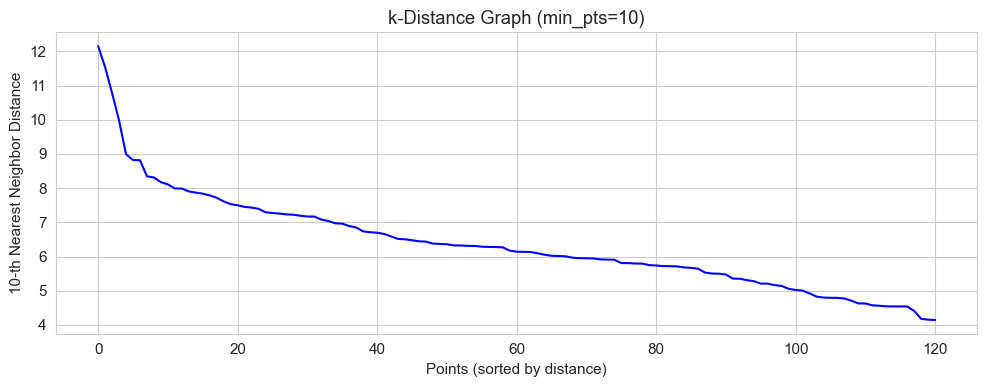


DBSCAN outlier detection (min_pts=10):
  eps=3.0: 0 clusters, 121 outliers
  eps=4.0: 0 clusters, 121 outliers
  eps=5.0: 1 clusters, 83 outliers
  eps=6.0: 1 clusters, 33 outliers
  eps=7.0: 1 clusters, 11 outliers


In [9]:
# k-distance graph to find epsilon
min_pts = min(2 * X.shape[1] + 1, 10)  # cap at 10 for small dataset
nn = NearestNeighbors(n_neighbors=min_pts)
nn.fit(X)
distances, _ = nn.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(k_distances)), k_distances, 'b-')
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{min_pts}-th Nearest Neighbor Distance')
ax.set_title(f'k-Distance Graph (min_pts={min_pts})')
plt.tight_layout()
plt.show()

# Try a range of epsilon values to find outliers
print(f"\nDBSCAN outlier detection (min_pts={min_pts}):")
for eps in [3.0, 4.0, 5.0, 6.0, 7.0]:
    db = DBSCAN(eps=eps, min_samples=min_pts)
    db_labels = db.fit_predict(X)
    n_outliers = (db_labels == -1).sum()
    n_clusters = len(set(db_labels) - {-1})
    
    outlier_names = [school_names[i] for i in range(len(school_names)) if db_labels[i] == -1]
    outlier_ranks = [int(ranks[i]) for i in range(len(school_names)) if db_labels[i] == -1]
    
    print(f"  eps={eps:.1f}: {n_clusters} clusters, {n_outliers} outliers", end="")
    if n_outliers > 0 and n_outliers <= 10:
        names_short = [f"{n[:20]}(r{r})" for n, r in zip(outlier_names, outlier_ranks)]
        print(f" → {', '.join(names_short)}")
    else:
        print()

## Step 2.5 — Cluster Stability Assessment

Bootstrap stability (n=100):
  Mean ARI: 0.554 ± 0.123
  Stability: MODERATE



GWU stability (leave-one-out, n=20):
  Stable assignments: 17/20 (85%)


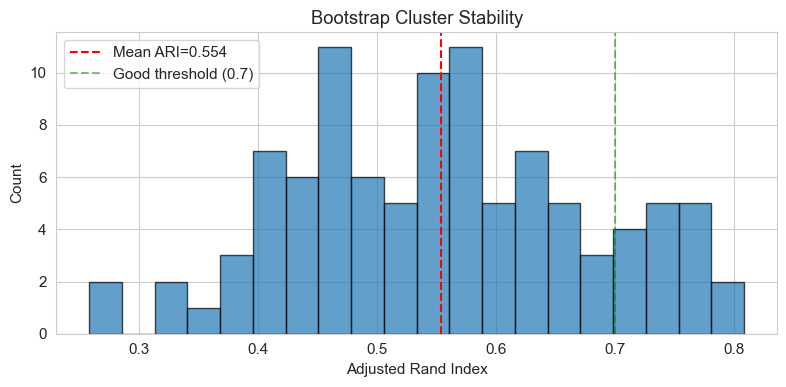

In [10]:
# Bootstrap stability: resample 100 times, compute ARI vs original
rng = np.random.RandomState(42)
n_bootstrap = 100
ari_scores = []

for b in range(n_bootstrap):
    # Bootstrap sample (with replacement)
    boot_idx = rng.choice(len(X), size=len(X), replace=True)
    X_boot = X[boot_idx]
    
    km_boot = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42, max_iter=300)
    boot_labels_raw = km_boot.fit_predict(X_boot)
    
    # Compare only on the overlapping indices
    # Map boot labels to best match original labels
    original_labels_boot = kmeans_labels[boot_idx]
    ari_b = adjusted_rand_score(original_labels_boot, boot_labels_raw)
    ari_scores.append(ari_b)

mean_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)
print(f"Bootstrap stability (n={n_bootstrap}):")
print(f"  Mean ARI: {mean_ari:.3f} ± {std_ari:.3f}")
print(f"  Stability: {'GOOD' if mean_ari > 0.7 else 'MODERATE' if mean_ari > 0.5 else 'POOR'}")

# Leave-one-out for GWU: check if GWU's peers change
gwu_stable_count = 0
n_loo = 20  # sample 20 LOO iterations for speed
loo_rng = np.random.RandomState(123)
loo_indices = loo_rng.choice([i for i in range(len(X)) if i != gwu_idx], size=n_loo, replace=False)

for drop_idx in loo_indices:
    mask = np.ones(len(X), dtype=bool)
    mask[drop_idx] = False
    X_loo = X[mask]
    
    km_loo = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=42, max_iter=300)
    loo_labels = km_loo.fit_predict(X_loo)
    
    # Find GWU's index in the reduced dataset
    gwu_loo_idx = gwu_idx if drop_idx > gwu_idx else gwu_idx - 1
    gwu_loo_cluster = loo_labels[gwu_loo_idx]
    
    # Check if same peers are in the same cluster
    original_gwu_peers = set(np.where(kmeans_labels == kmeans_labels[gwu_idx])[0])
    loo_peers = set(np.where(mask)[0][loo_labels == gwu_loo_cluster])
    overlap = len(original_gwu_peers & loo_peers) / len(original_gwu_peers)
    if overlap > 0.7:
        gwu_stable_count += 1

print(f"\nGWU stability (leave-one-out, n={n_loo}):")
print(f"  Stable assignments: {gwu_stable_count}/{n_loo} ({100*gwu_stable_count/n_loo:.0f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ari_scores, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(x=mean_ari, color='r', linestyle='--', label=f'Mean ARI={mean_ari:.3f}')
ax.axvline(x=0.7, color='g', linestyle='--', alpha=0.5, label='Good threshold (0.7)')
ax.set_xlabel('Adjusted Rand Index')
ax.set_ylabel('Count')
ax.set_title('Bootstrap Cluster Stability')
ax.legend()
plt.tight_layout()
plt.show()

## Step 2.6 — Visualizations

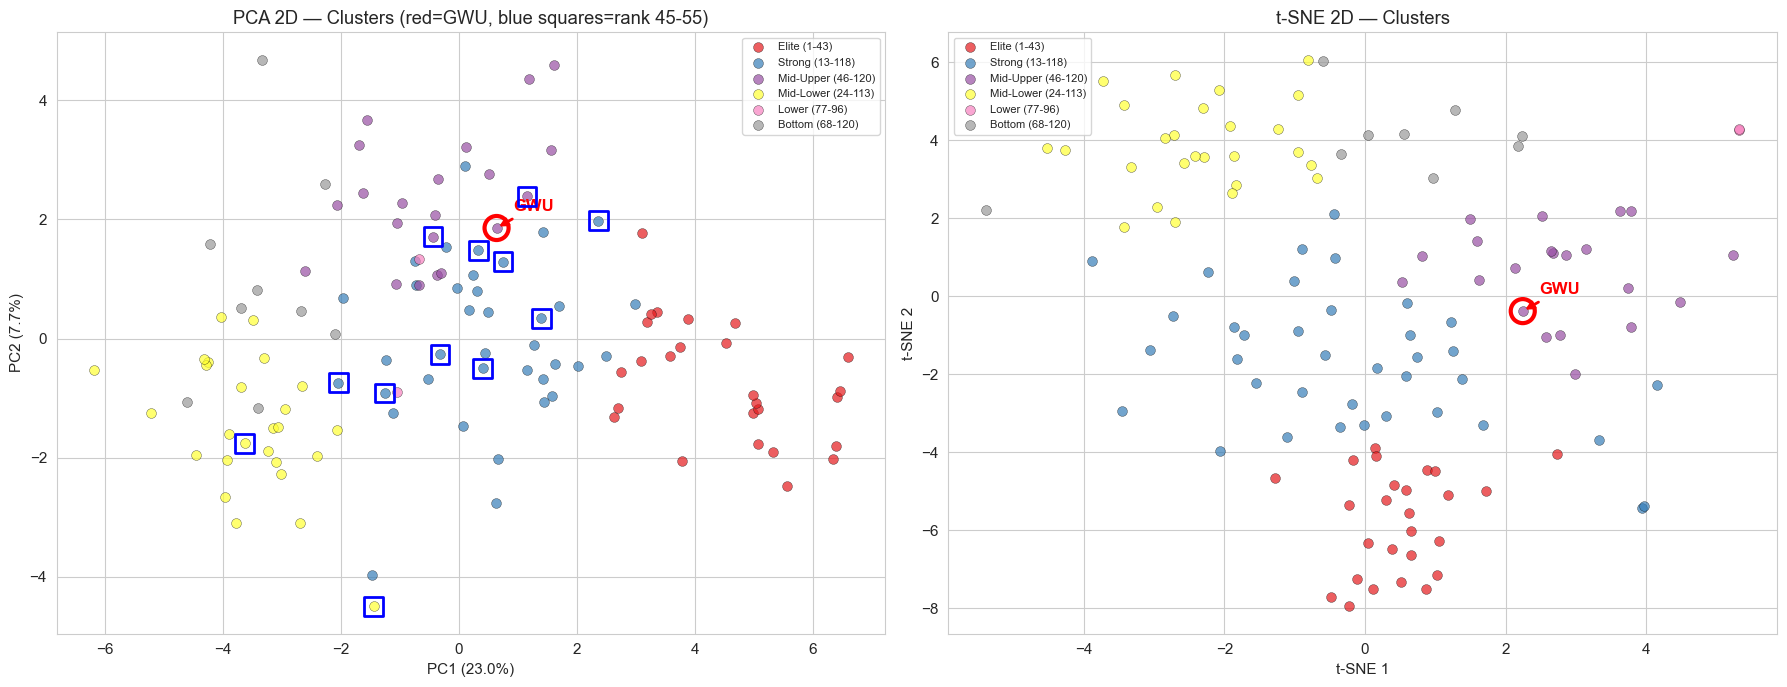

In [11]:
# Color palette for clusters
cluster_colors = plt.cm.Set1(np.linspace(0, 1, OPTIMAL_K))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── PCA 2D scatter ──
for c in range(OPTIMAL_K):
    mask = kmeans_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[cluster_colors[c]], 
                   s=50, alpha=0.7, edgecolors='k', linewidth=0.3,
                   label=cluster_names[c])

# Highlight GWU
axes[0].scatter(X_pca[gwu_idx, 0], X_pca[gwu_idx, 1], c='none', s=300,
               edgecolors='red', linewidth=3, zorder=5)
axes[0].annotate('GWU', xy=(X_pca[gwu_idx, 0], X_pca[gwu_idx, 1]),
                xytext=(12, 12), textcoords='offset points', fontsize=12,
                fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

# Highlight rank 45-55 schools
for idx in np.where((ranks >= 45) & (ranks <= 55))[0]:
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1], c='none', s=180,
                   edgecolors='blue', linewidth=2, zorder=4, marker='s')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('PCA 2D — Clusters (red=GWU, blue squares=rank 45-55)')
axes[0].legend(fontsize=8, loc='best')

# ── t-SNE 2D scatter ──
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X)

for c in range(OPTIMAL_K):
    mask = kmeans_labels == c
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=[cluster_colors[c]],
                   s=50, alpha=0.7, edgecolors='k', linewidth=0.3,
                   label=cluster_names[c])

axes[1].scatter(X_tsne[gwu_idx, 0], X_tsne[gwu_idx, 1], c='none', s=300,
               edgecolors='red', linewidth=3, zorder=5)
axes[1].annotate('GWU', xy=(X_tsne[gwu_idx, 0], X_tsne[gwu_idx, 1]),
                xytext=(12, 12), textcoords='offset points', fontsize=12,
                fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE 2D — Clusters')
axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

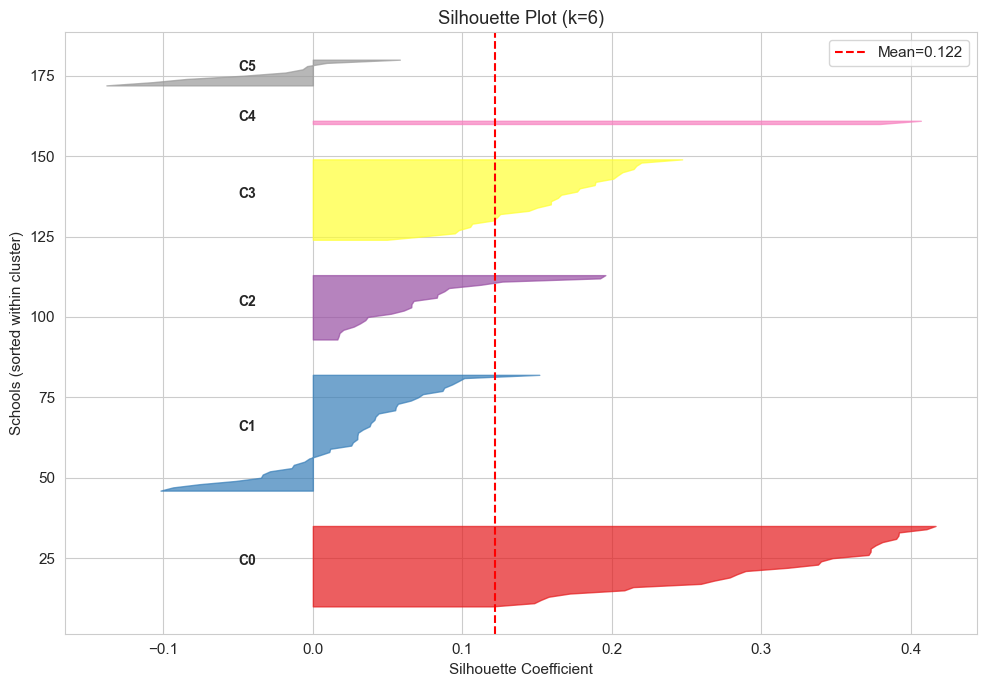

GWU silhouette score: 0.032
GWU cluster mean silhouette: 0.071
Overall mean silhouette: 0.122


In [12]:
# Silhouette plot
sil_samples = silhouette_samples(X, kmeans_labels)
sil_avg = silhouette_score(X, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for c in range(OPTIMAL_K):
    c_sil = sil_samples[kmeans_labels == c]
    c_sil.sort()
    c_size = len(c_sil)
    y_upper = y_lower + c_size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=cluster_colors[c], edgecolor=cluster_colors[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * c_size, f'C{c}', fontsize=10, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', label=f'Mean={sil_avg:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Schools (sorted within cluster)')
ax.set_title(f'Silhouette Plot (k={OPTIMAL_K})')
ax.legend()
plt.tight_layout()
plt.show()

# GWU's silhouette score
gwu_sil = sil_samples[gwu_idx]
gwu_cluster_mean_sil = sil_samples[kmeans_labels == kmeans_labels[gwu_idx]].mean()
print(f"GWU silhouette score: {gwu_sil:.3f}")
print(f"GWU cluster mean silhouette: {gwu_cluster_mean_sil:.3f}")
print(f"Overall mean silhouette: {sil_avg:.3f}")

## Step 2.7 — Save Clustering Artifacts

In [13]:
# Identify GWU's cluster and the aspiration cluster
gwu_cluster_id = kmeans_labels[gwu_idx]
# Aspiration cluster = the one just above GWU's cluster (lower cluster_id = higher ranked)
aspiration_cluster_id = max(0, gwu_cluster_id - 1)

print(f"GWU cluster:       {gwu_cluster_id} — {cluster_names[gwu_cluster_id]}")
print(f"Aspiration cluster: {aspiration_cluster_id} — {cluster_names[aspiration_cluster_id]}")

clustering_artifacts = {
    'OPTIMAL_K': OPTIMAL_K,
    'kmeans_labels': kmeans_labels,
    'kmeans_centroids': kmeans_centroids,
    'cluster_names': cluster_names,
    'cluster_assignments': cluster_assignments,
    'hier_labels': hier_labels,
    'gwu_cluster_id': gwu_cluster_id,
    'aspiration_cluster_id': aspiration_cluster_id,
    'sil_avg': sil_avg,
    'sil_samples': sil_samples,
    'X_tsne': X_tsne,
    'bootstrap_ari_mean': mean_ari,
    'Z_linkage': Z,
}

with open('clustering_artifacts.pkl', 'wb') as f:
    pickle.dump(clustering_artifacts, f)

print(f"\nSaved: clustering_artifacts.pkl")
print(f"  k={OPTIMAL_K}, silhouette={sil_avg:.3f}, bootstrap ARI={mean_ari:.3f}")
print(f"\nNext: 03_cluster_profiling_gwu.ipynb")

GWU cluster:       2 — Mid-Upper (46-120)
Aspiration cluster: 1 — Strong (13-118)

Saved: clustering_artifacts.pkl
  k=6, silhouette=0.122, bootstrap ARI=0.554

Next: 03_cluster_profiling_gwu.ipynb
